# Marathi TTS fine-tuning — Bodhan Indic-Speak + AI4Bharat Rasa

QLoRA training notebook for a CUDA GPU, followed by adapter reload and WAV generation with Bodhan's official Vocos inference code.

**Status:** notebook structure and Python syntax validated; packing and tensor checks are included for execution in your runtime; gated model/dataset downloads and GPU training have not been executed by the author. Runtime preflight checks deliberately stop on incompatible tokenizer/source or ambiguous dataset columns rather than silently training the wrong format.

Start in a fresh Colab/Linux GPU runtime. Accept access conditions at [Indic-Speak](https://huggingface.co/bodhan-ai/indic-speak) and [Rasa Marathi](https://huggingface.co/datasets/ai4bharat/Rasa/viewer/Marathi). A 24 GB or larger CUDA GPU is a practical starting point, not a measured guarantee; memory depends on sequence length. The default runs one complete epoch over every decodable Marathi `train` row of both genders and every style, with a separate evaluation on the official `test` split; expect substantially more preprocessing and GPU time than a 500-row smoke run.

This is newly written code informed by the supplied Unsloth Orpheus notebook. It uses Transformers + PEFT because Indic-Speak's model card requires Transformers v5. The generic `pipeline("text-to-speech", ...)` snippet is not a training API and does not describe this model's custom Vocos path.

In [2]:
%pip install -q "transformers>=5,<6" "peft>=0.18" "accelerate>=1.2" "bitsandbytes>=0.45" "datasets>=3.4,<4" "huggingface_hub>=1" snac soundfile scipy librosa matplotlib
# Restart the kernel after this cell if these libraries were already imported.
# Keep the runtime's matching torch/torchaudio installation; do not replace torch alone.

Note: you may need to restart the kernel to use updated packages.


## 1. Settings and authentication
Rasa Marathi exposes `filename`, `text`, `language`, `gender`, `style`, `duration`, `wav_path`, and `audio`. The run includes **all styles and both genders** in each official split. The `train` split has about 27k rows and the separate `test` split about 3k. Since there is no speaker ID, separate `MarathiRasaMale` and `MarathiRasaFemale` labels indicate gender groups, not verified individual voices. No row-count, duration, or token-length filter is applied. Rows with missing text/audio, unreadable audio, or a context length beyond the model's configured capacity are counted and excluded.

In [3]:
import os, sys, json, random, gc, re, io, hashlib, inspect, importlib, subprocess
from pathlib import Path
import numpy as np
import torch
from huggingface_hub import HfApi, login, snapshot_download
from getpass import getpass

MODEL_ID = "bodhan-ai/indic-speak"
DATASET_ID = "ai4bharat/Rasa"
DATASET_CONFIG = "Marathi"
TRAIN_SPLIT = "train"
TEST_SPLIT = "test"
SEED = 3407
MAX_SEQ_LENGTH = None  # no token-length filter; check model context capacity at runtime
NUM_EPOCHS = 1
MIN_SECONDS = 0.0  # zero-length/corrupt recordings cannot be encoded
LORA_R = 16
LORA_ALPHA = 32
LEARNING_RATE = 1e-4
GRAD_ACCUM = 8
SPEAKER_BY_GENDER = {"MALE":"MarathiRasaMale", "FEMALE":"MarathiRasaFemale", "M":"MarathiRasaMale", "F":"MarathiRasaFemale"}
AUDIO_COLUMN = "audio"
TEXT_COLUMN = "text"
GENDER_COLUMN = "gender"
STYLE_COLUMN = "style"
FILENAME_COLUMN = "filename"
OUT = Path("indic_speak_marathi_run").resolve()
OUT.mkdir(exist_ok=True)
assert torch.cuda.is_available(), "Select a CUDA GPU runtime before continuing."
BF16 = torch.cuda.is_bf16_supported()
COMPUTE_DTYPE = torch.bfloat16 if BF16 else torch.float16
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
print(torch.cuda.get_device_name(0), "VRAM GiB:", round(torch.cuda.get_device_properties(0).total_memory/2**30, 1))
print("Compute:", COMPUTE_DTYPE)
# Input is hidden and is not written into notebook outputs or run metadata.
if not os.environ.get("HF_TOKEN"):
    login(token=getpass("Hugging Face read token: "), add_to_git_credential=False)
api = HfApi()
MODEL_REVISION = api.model_info(MODEL_ID).sha
DATA_REVISION = api.dataset_info(DATASET_ID).sha
print("Model revision:", MODEL_REVISION, "Dataset revision:", DATA_REVISION)

NVIDIA H200 VRAM GiB: 139.8
Compute: torch.bfloat16
Model revision: 76e0814f189321efe550011850cd288dae366aad Dataset revision: 632f55c7ac590219d41cd7adffce5b440e4604f5


## 2. Download model support files; validate tokenizer and prompt
The official card specifies speaker markup followed by human/AI/speech delimiters. This notebook does not use the Orpheus `speaker: text` prompt. Audio packing below uses the Orpheus/SNAC seven-slot layout and requires confirmation against the downloaded Bodhan inference source before training.

Only support files are downloaded here. Model weights are fetched at training time.

In [4]:
from transformers import AutoTokenizer, AutoConfig
support_dir = Path(snapshot_download(
    MODEL_ID, revision=MODEL_REVISION,
    allow_patterns=["*.py", "*.json", "*.md", "LICENSE*", "vocos/*"],
))
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, revision=MODEL_REVISION)
config = AutoConfig.from_pretrained(MODEL_ID, revision=MODEL_REVISION)
source_path = support_dir / "inference.py"
assert source_path.exists(), "Expected official inference.py is missing. Inspect the new model revision."
source = source_path.read_text()
# Import the pinned repository's pure prompt/codec utilities without loading model weights.
import importlib.util
spec = importlib.util.spec_from_file_location("bodhan_inference_pinned", source_path)
indic_inference = importlib.util.module_from_spec(spec)
spec.loader.exec_module(indic_inference)
assert callable(indic_inference.build_prompt) and callable(indic_inference.ids_to_codes)

def token_id(s):
    ids = tokenizer.encode(s, add_special_tokens=False)
    assert len(ids) == 1 and tokenizer.convert_ids_to_tokens(ids[0]) == s, (s, ids)
    return ids[0]
SOS = token_id("<|start_of_speech|>")
EOS = token_id("<|end_of_speech|>")
EOAI = token_id("<|end_of_ai|>")
for s in ["<|start_of_human|>", "<|begin_of_text|>", "<|eot_id|>", "<|end_of_human|>", "<|start_of_ai|>"]:
    token_id(s)
if tokenizer.pad_token_id is None:
    tokenizer.pad_token = "<|end_of_speech|>"
tokenizer.padding_side = "right"

AUDIO_BASE = tokenizer.convert_tokens_to_ids("<|snac_0|>")
CODEBOOK_SIZE = indic_inference.CODEBOOK_SIZE
assert indic_inference.NUM_CODEBOOKS == 7 and CODEBOOK_SIZE == 4096
assert AUDIO_BASE == 128266, f"Unexpected SNAC base: {AUDIO_BASE}"
print("Audio boundary tokens:", tokenizer.convert_ids_to_tokens([AUDIO_BASE, AUDIO_BASE + 7*4096-1]))
print("Vocabulary:", config.vocab_size)
assert AUDIO_BASE + 7*CODEBOOK_SIZE <= config.vocab_size

def prompt_ids(text, style, speaker_label):
    # Use Bodhan's exact prompt construction, including BOS and metadata separators.
    ids = indic_inference.build_prompt(tokenizer, text, speaker=speaker_label, style=style)
    assert ids[-1] == SOS
    return ids
print(tokenizer.decode(prompt_ids("नमस्कार, तुम्ही कसे आहात?", "NEUTRAL", "MarathiRasaMale")))

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 18 files:   0%|          | 0/18 [00:00<?, ?it/s]

[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


Audio boundary tokens: ['<|snac_0|>', '<|snac_28671|>']
Vocabulary: 156960
<|start_of_human|><|begin_of_text|><|speaker>MarathiRasaMale<speaker|>
<|style>NEUTRAL<style|>
नमस्कार, तुम्ही कसे आहात?<|eot_id|><|end_of_human|><|start_of_ai|><|start_of_speech|>


The notebook imports `build_prompt` and `ids_to_codes` from the **same pinned Indic-Speak revision** used for training. It checks the tokenizer's SNAC base, seven codebooks, and a synthetic audio-code round trip against Bodhan's implementation. If the upstream format changes, this cell stops with a specific error. The text/audio pipeline remains separate from the generic Transformers TTS pipeline.

In [5]:
def pack_codes(codes):
    c0, c1, c2 = [c.detach().cpu().long().reshape(-1) for c in codes]
    N = len(c0)
    assert len(c1) == 2*N and len(c2) == 4*N, "Unexpected SNAC level lengths"
    frame = torch.stack([c0, c1[0::2], c2[0::4], c2[1::4], c1[1::2], c2[2::4], c2[3::4]], dim=1)
    assert frame.min() >= 0 and frame.max() < CODEBOOK_SIZE
    return (frame + AUDIO_BASE + torch.arange(7)*CODEBOOK_SIZE).reshape(-1).tolist()

def unpack_codes(tokens):
    assert len(tokens) > 0 and len(tokens) % 7 == 0
    frame = torch.tensor(tokens).reshape(-1,7) - AUDIO_BASE - torch.arange(7)*CODEBOOK_SIZE
    assert frame.min() >= 0 and frame.max() < CODEBOOK_SIZE
    return [frame[:,0].reshape(1,-1), frame[:,[1,4]].reshape(1,-1), frame[:,[2,3,5,6]].reshape(1,-1)]

fake = [torch.arange(3).reshape(1,-1), torch.arange(6).reshape(1,-1), torch.arange(12).reshape(1,-1)]
packed = pack_codes(fake)
assert all(torch.equal(a,b) for a,b in zip(fake, unpack_codes(packed)))
official = indic_inference.ids_to_codes(packed + [EOS], AUDIO_BASE, "cpu")
assert all(torch.equal(a,b) for a,b in zip(fake, official)), "Packed SNAC codes disagree with official decoder."
print("SNAC layout verified against Bodhan's pinned inference.py.")

SNAC layout verified against Bodhan's pinned inference.py.


## 3. Load the official Marathi train and test splits
The viewer shows `train` (~27k) and `test` (~3k). We keep those exact source splits: train the adapter only on `train`, then evaluate once on `test`. The viewer's icon/type labels are UI decoration. The dataset fields are `filename`, `text`, `language`, `gender`, `style`, `duration`, `wav_path`, and `audio`.

In [6]:
from datasets import load_dataset, Audio as HFAudio, Dataset
import soundfile as sf
from scipy.signal import resample_poly
from math import gcd

raw_splits = {
    split: load_dataset(DATASET_ID, DATASET_CONFIG, split=split, streaming=True, revision=DATA_REVISION)
    for split in (TRAIN_SPLIT, TEST_SPLIT)
}
required = [AUDIO_COLUMN, TEXT_COLUMN, GENDER_COLUMN, STYLE_COLUMN, FILENAME_COLUMN]
for split, ds in raw_splits.items():
    print(split, "features:", ds.features)
    missing = [name for name in required if name not in ds.features]
    assert not missing, f"Missing Rasa columns in {split}: {missing}"
    assert isinstance(ds.features[AUDIO_COLUMN], HFAudio)
    raw_splits[split] = ds.cast_column(AUDIO_COLUMN, HFAudio(decode=False))
for split, ds in raw_splits.items():
    row = next(iter(ds))
    print(split, "non-audio example:", {k:v for k,v in row.items() if k != AUDIO_COLUMN})
def decode_audio(a):
    handle = io.BytesIO(a["bytes"]) if a.get("bytes") is not None else a["path"]
    wav, sr = sf.read(handle, dtype="float32", always_2d=True)
    wav = wav.mean(axis=1)
    assert wav.size and np.isfinite(wav).all(), "Invalid waveform"
    if sr != 24000:
        divisor = gcd(int(sr), 24000)
        wav = resample_poly(wav, 24000//divisor, int(sr)//divisor).astype(np.float32)
    return wav


Resolving data files:   0%|          | 0/59 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/57 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/59 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/57 [00:00<?, ?it/s]

train features: {'filename': Value(dtype='string', id=None), 'text': Value(dtype='string', id=None), 'language': Value(dtype='string', id=None), 'gender': Value(dtype='string', id=None), 'style': Value(dtype='string', id=None), 'duration': Value(dtype='string', id=None), 'wav_path': Value(dtype='string', id=None), 'audio': Audio(sampling_rate=None, mono=True, decode=True, id=None)}
test features: {'filename': Value(dtype='string', id=None), 'text': Value(dtype='string', id=None), 'language': Value(dtype='string', id=None), 'gender': Value(dtype='string', id=None), 'style': Value(dtype='string', id=None), 'duration': Value(dtype='string', id=None), 'wav_path': Value(dtype='string', id=None), 'audio': Audio(sampling_rate=None, mono=True, decode=True, id=None)}
train non-audio example: {'filename': 'MAR_M_SAD_00069', 'text': 'या गावातल्या प्रत्येक दुकानात फोन लावून बघितला मी, पण त्यांच्याकडे डिशवॉशरच नाहीये विकायला.', 'language': 'Marathi', 'gender': 'Male', 'style': 'SAD', 'duration': '7

## 4. Encode all usable rows in each official split with frozen SNAC
No gender, style, row-count, duration, or arbitrary token-length filter is applied. Invalid examples are counted **per split**. The SNAC encoder makes target audio tokens; training labels mask the text prompt. The official test split stays isolated from model updates and is evaluated after training. Filename/audio overlap between train and test is reported because it can bias the result.
**Audio fertility** here means SNAC base frames per whitespace-delimited transcript word. A frame corresponds to one seven-code group in this notebook, so serialized-code fertility is exactly seven times frame fertility. This is a data diagnostic, not an audio-quality or transcription metric. Word segmentation by whitespace is an approximation for Marathi.

In [7]:
from snac import SNAC
from collections import Counter
import unicodedata
snac = SNAC.from_pretrained("hubertsiuzdak/snac_24khz").eval().to("cuda")
encoded = {}
manifest = []
stats_by_split = {}
fertility_by_split = {}
for split_name, stream in raw_splits.items():
    examples, split_manifest = [], []
    stats = Counter()
    for index, row in enumerate(stream):
        stats["scanned"] += 1
        text = unicodedata.normalize("NFC", str(row[TEXT_COLUMN] or "")).strip()
        gender = str(row[GENDER_COLUMN] or "").strip().upper()
        style = str(row[STYLE_COLUMN] or "").strip().upper()
        filename = str(row[FILENAME_COLUMN] or "")
        language = str(row.get("language") or "")
        if not text or not gender or not style or not filename:
            stats["empty_metadata"] += 1; continue
        speaker_label = SPEAKER_BY_GENDER.get(gender)
        if not speaker_label:
            stats["unknown_gender"] += 1; continue
        try:
            wav = decode_audio(row[AUDIO_COLUMN])
        except Exception as exc:
            stats["decode_error"] += 1
            if stats["decode_error"] <= 3:
                print(split_name, "audio decode error:", type(exc).__name__, str(exc)[:160])
            continue
        duration = len(wav)/24000
        if duration <= MIN_SECONDS or np.max(np.abs(wav)) < 1e-4:
            stats["empty_or_silent"] += 1; continue
        try:
            with torch.inference_mode():
                codes = snac.encode(torch.tensor(wav, device="cuda")[None,None,:])
            audio_ids = pack_codes(codes)
        except Exception as exc:
            stats["snac_encode_error"] += 1
            if stats["snac_encode_error"] <= 3:
                print(split_name, "SNAC encode error:", type(exc).__name__, str(exc)[:160])
            continue
        # SNAC level-0 count equals the number of seven-code audio frames.
        # Count words in the original transcript; do not include speaker/style markup.
        word_count = len(text.split())
        frame_count = len(audio_ids) // 7
        assert len(audio_ids) == 7 * frame_count and word_count > 0
        frames_per_word = frame_count / word_count
        audio_tokens_per_word = len(audio_ids) / word_count
        prefix = prompt_ids(text, style, speaker_label)
        target = audio_ids + [EOS, EOAI]
        ids = prefix + target
        if len(ids) > config.max_position_embeddings:
            stats["exceeds_model_context"] += 1; continue
        examples.append({"input_ids":ids, "attention_mask":[1]*len(ids),
                         "labels":[-100]*len(prefix)+target})
        split_manifest.append({"split":split_name, "text":text, "filename":filename,
            "language":language, "gender":gender, "style":style,
            "speaker_label":speaker_label, "duration":duration,
            "source_duration":row.get("duration"), "wav_path":str(row.get("wav_path") or ""),
            "audio_sha256":hashlib.sha256(wav.tobytes()).hexdigest(), "tokens":len(ids),
            "word_count":word_count, "snac_frame_count":frame_count,
            "audio_token_count":len(audio_ids),
            "snac_frames_per_word":round(frames_per_word, 4),
            "audio_tokens_per_word":round(audio_tokens_per_word, 4)})
        if len(examples) <= 2:
            sf.write(OUT/f"reference_{split_name}_{len(examples)}.wav", wav, 24000)
        if len(examples)%500 == 0:
            print(split_name, "encoded", len(examples), "of", stats["scanned"], "scanned")
    assert len(examples) >= 20, f"Only {len(examples)} valid {split_name} rows: {stats}"
    stats_by_split[split_name] = dict(stats)
    manifest.extend(split_manifest)
    encoded[split_name] = Dataset.from_list(examples)
    encoded[split_name].save_to_disk(str(OUT/f"{split_name}_tokens"))
    print(split_name, "accepted",len(examples),"of",stats["scanned"])
    print("Gender:",dict(Counter(m["gender"] for m in split_manifest)))
    print("Style:",dict(Counter(m["style"] for m in split_manifest)))
    print("Token lengths (min, median, p95, max):",
          np.percentile([m["tokens"] for m in split_manifest],[0,50,95,100]))
    ratios = np.asarray([m["snac_frames_per_word"] for m in split_manifest])
    summary = {"clips":len(ratios),
               "total_words":sum(m["word_count"] for m in split_manifest),
               "total_snac_frames":sum(m["snac_frame_count"] for m in split_manifest),
               "mean_frames_per_word":round(float(ratios.mean()), 4),
               "median_frames_per_word":round(float(np.median(ratios)), 4),
               "p05_frames_per_word":round(float(np.percentile(ratios, 5)), 4),
               "p95_frames_per_word":round(float(np.percentile(ratios, 95)), 4)}
    summary["corpus_frames_per_word"] = round(summary["total_snac_frames"] / summary["total_words"], 4)
    fertility_by_split[split_name] = summary
    print("Audio fertility:", summary)
    # Review extremes without discarding them from the dataset.
    extremes = sorted(split_manifest, key=lambda m: m["snac_frames_per_word"])
    for m in extremes[:3] + extremes[-3:]:
        print("  ", m["filename"], m["word_count"], "words,",
              m["snac_frame_count"], "frames,",
              m["snac_frames_per_word"], "frames/word")
train_ds = encoded[TRAIN_SPLIT]
test_ds = encoded[TEST_SPLIT]
test_manifest = [m for m in manifest if m["split"] == TEST_SPLIT]
train_manifest = [m for m in manifest if m["split"] == TRAIN_SPLIT]
overlap = {
    "filename": len({m["filename"] for m in train_manifest} & {m["filename"] for m in test_manifest}),
    "audio_sha256": len({m["audio_sha256"] for m in train_manifest} & {m["audio_sha256"] for m in test_manifest}),
    "exact_text": len({m["text"] for m in train_manifest} & {m["text"] for m in test_manifest}),
}
print("Train/test overlap:", overlap)
(OUT/"manifest.json").write_text(json.dumps(manifest, ensure_ascii=False, indent=2))
(OUT/"preprocessing_stats.json").write_text(json.dumps(
    {"splits":stats_by_split, "fertility":fertility_by_split, "overlap":overlap}, indent=2))
(OUT/"audio_fertility.json").write_text(json.dumps(fertility_by_split, indent=2))
del snac; gc.collect(); torch.cuda.empty_cache()
print(train_ds, test_ds)

train encoded 500 of 500 scanned
train encoded 1000 of 1000 scanned
train encoded 1500 of 1500 scanned
train encoded 2000 of 2000 scanned
train encoded 2500 of 2500 scanned
train encoded 3000 of 3000 scanned
train encoded 3500 of 3500 scanned
train encoded 4000 of 4000 scanned
train encoded 4500 of 4500 scanned
train encoded 5000 of 5000 scanned
train encoded 5500 of 5500 scanned
train encoded 6000 of 6000 scanned
train encoded 6500 of 6500 scanned
train encoded 7000 of 7000 scanned
train encoded 7500 of 7500 scanned
train encoded 8000 of 8000 scanned
train encoded 8500 of 8500 scanned
train encoded 9000 of 9000 scanned
train encoded 9500 of 9500 scanned
train encoded 10000 of 10000 scanned
train encoded 10500 of 10500 scanned
train encoded 11000 of 11000 scanned
train encoded 11500 of 11500 scanned
train encoded 12000 of 12000 scanned
train encoded 12500 of 12500 scanned
train encoded 13000 of 13000 scanned
train encoded 13500 of 13500 scanned
train encoded 14000 of 14000 scanned
trai

Saving the dataset (0/1 shards):   0%|          | 0/26960 [00:00<?, ? examples/s]

train accepted 26960 of 26960
Gender: {'MALE': 13036, 'FEMALE': 13924}
Style: {'SAD': 823, 'WIKI': 5844, 'INDIC': 1068, 'NEWS': 1493, 'CONV': 4659, 'BOOK': 2174, 'PROPER NOUN': 4997, 'UMANG': 221, 'DISGUST': 836, 'ALEXA': 699, 'HAPPY': 895, 'FEAR': 898, 'ANGER': 975, 'BB': 356, 'SURPRISE': 794, 'DIGI': 228}
Token lengths (min, median, p95, max): [  60.    546.   1340.05 3878.  ]
Audio fertility: {'clips': 26960, 'total_words': 305293, 'total_snac_frames': 2116724, 'mean_frames_per_word': 7.602, 'median_frames_per_word': 7.0, 'p05_frames_per_word': 4.8333, 'p95_frames_per_word': 12.5, 'corpus_frames_per_word': 6.9334}
   MAR_M_BOOK_00800 17 words, 11 frames, 0.6471 frames/word
   MAR_M_BOOK_00808 11 words, 10 frames, 0.9091 frames/word
   MAR_M_BOOK_00827 13 words, 13 frames, 1.0 frames/word
   MAR_M_NAMES_00949 1 words, 28 frames, 28.0 frames/word
   MAR_M_NAMES_01157 1 words, 29 frames, 29.0 frames/word
   MAR_M_NAMES_00882 1 words, 30 frames, 30.0 frames/word
test encoded 500 of 500 

Saving the dataset (0/1 shards):   0%|          | 0/2995 [00:00<?, ? examples/s]

test accepted 2995 of 2995
Gender: {'MALE': 1447, 'FEMALE': 1548}
Style: {'SAD': 91, 'WIKI': 650, 'PROPER NOUN': 555, 'UMANG': 24, 'INDIC': 119, 'BOOK': 241, 'ANGER': 109, 'CONV': 517, 'BB': 39, 'DISGUST': 93, 'NEWS': 166, 'ALEXA': 78, 'FEAR': 99, 'DIGI': 26, 'SURPRISE': 88, 'HAPPY': 100}
Token lengths (min, median, p95, max): [  66.  548. 1338. 2855.]
Audio fertility: {'clips': 2995, 'total_words': 33840, 'total_snac_frames': 233611, 'mean_frames_per_word': 7.5799, 'median_frames_per_word': 7.0, 'p05_frames_per_word': 4.8967, 'p95_frames_per_word': 12.3333, 'corpus_frames_per_word': 6.9034}
   MAR_M_CONV_01487 7 words, 22 frames, 3.1429 frames/word
   MAR_M_CONV_02201 7 words, 23 frames, 3.2857 frames/word
   MAR_M_CONV_02308 7 words, 24 frames, 3.4286 frames/word
   MAR_M_NAMES_00134 1 words, 25 frames, 25.0 frames/word
   MAR_M_NAMES_00965 1 words, 26 frames, 26.0 frames/word
   MAR_M_NAMES_00154 1 words, 28 frames, 28.0 frames/word
Train/test overlap: {'filename': 0, 'audio_sha256'

## 5. Fine-tune only on official train; evaluate on official test
The LM uses NF4 with rank-16 adapters and trains for one full epoch of the accepted `train` rows. The `test` examples never enter optimization, scheduler selection, checkpoint selection, or hyperparameter tuning. They are evaluated once after training. Long recordings may exceed 24 GB activation memory even at batch size 1; inspect the printed token-length distribution before starting.

In [8]:
from transformers import AutoModelForCausalLM, BitsAndBytesConfig, Trainer, TrainingArguments
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

qconfig = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True, bnb_4bit_compute_dtype=COMPUTE_DTYPE)
model = AutoModelForCausalLM.from_pretrained(MODEL_ID, revision=MODEL_REVISION,
    quantization_config=qconfig, dtype=COMPUTE_DTYPE, device_map={"":0}, attn_implementation="sdpa")
model.config.use_cache = False
model = prepare_model_for_kbit_training(model, use_gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant":False})
model = get_peft_model(model, LoraConfig(r=LORA_R, lora_alpha=LORA_ALPHA,
    target_modules=["q_proj","k_proj","v_proj","o_proj","gate_proj","up_proj","down_proj"],
    lora_dropout=0.05, bias="none", task_type="CAUSAL_LM"))
model.print_trainable_parameters()

class AudioCollator:
    def __call__(self, rows):
        length = ((max(len(r["input_ids"]) for r in rows)+7)//8)*8
        out = {k:[] for k in ["input_ids", "attention_mask", "labels"]}
        for r in rows:
            pad = length-len(r["input_ids"])
            out["input_ids"].append(r["input_ids"]+[tokenizer.pad_token_id]*pad)
            out["attention_mask"].append(r["attention_mask"]+[0]*pad)
            out["labels"].append(r["labels"]+[-100]*pad)
        return {k:torch.tensor(v, dtype=torch.long) for k,v in out.items()}
collator = AudioCollator()
batch = {k:v.to("cuda") for k,v in collator([train_ds[0]]).items()}
model.eval()
with torch.no_grad(), torch.autocast("cuda", dtype=COMPUTE_DTYPE):
    smoke_loss = model(**batch).loss
assert torch.isfinite(smoke_loss), "Non-finite initial loss: stop and inspect labels/token format."
print("Initial loss:", smoke_loss.item())
del batch, smoke_loss
model.train()

args = TrainingArguments(output_dir=str(OUT/"checkpoints"),
    per_device_train_batch_size=1, per_device_eval_batch_size=1,
    # group_by_length=False,
    gradient_accumulation_steps=GRAD_ACCUM, num_train_epochs=NUM_EPOCHS, max_steps=-1,
    learning_rate=LEARNING_RATE, warmup_steps=170, lr_scheduler_type="cosine",
    optim="paged_adamw_8bit", bf16=BF16, fp16=not BF16,
    gradient_checkpointing=True, gradient_checkpointing_kwargs={"use_reentrant":False},
    logging_steps=25, eval_strategy="no",
    save_strategy="steps", save_steps=1000, save_total_limit=2,
    load_best_model_at_end=False,
    prediction_loss_only=True, max_grad_norm=1.0, weight_decay=0.01,
    report_to="none", seed=SEED, data_seed=SEED, dataloader_num_workers=0)
trainer = Trainer(model=model, args=args, train_dataset=train_ds,
                  data_collator=collator, processing_class=tokenizer)
# Set to a checkpoint path to resume an interrupted run.
RESUME_FROM_CHECKPOINT = None
torch.cuda.reset_peak_memory_stats()
result = trainer.train(resume_from_checkpoint=RESUME_FROM_CHECKPOINT)
test_metrics = trainer.evaluate(eval_dataset=test_ds, metric_key_prefix="test")
metrics = {**result.metrics, **test_metrics,
           "peak_allocated_GiB":torch.cuda.max_memory_allocated()/2**30}
print(metrics)

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

trainable params: 24,313,856 || all params: 3,325,242,368 || trainable%: 0.7312


[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 128263}.


Initial loss: 4.638160228729248


Step,Training Loss
25,4.663248
50,4.355978
75,4.123363
100,3.987896
125,3.969899
150,3.940649
175,3.945716
200,3.926328
225,3.938156
250,3.903061


Training Loss,Validation Loss,Step
3.739665,3.739308,3370


{'train_runtime': 9594.4156, 'train_samples_per_second': 2.81, 'train_steps_per_second': 0.351, 'total_flos': 2.843633954257797e+17, 'train_loss': 3.8042677067153887, 'epoch': 1.0, 'test_loss': 3.7393081188201904, 'peak_allocated_GiB': 12.434263229370117}


## 6. Save adapters, logs, environment and loss plot
The saved adapter needs the exact base model revision. No automatic publishing occurs. These files and audio examples form the submission artifacts. Test loss measures audio-token prediction, not perceived speech quality; compare held-out generated audio too.
The manifest also contains per-clip word counts, SNAC frame counts, frames/word and serialized audio tokens/word. Split summaries are in `audio_fertility.json`. Extremely high or low ratios warrant manual transcript/audio review; the notebook does not exclude those rows automatically.

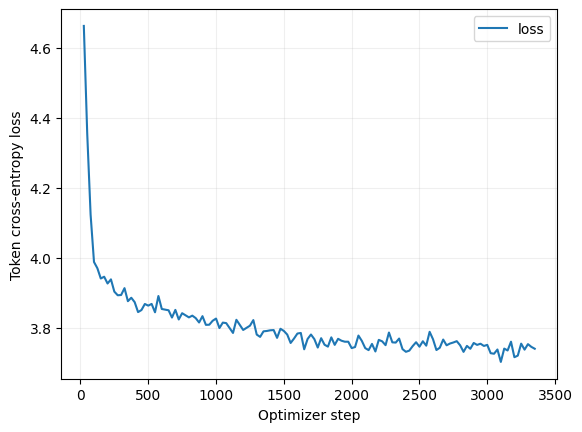

Saved: /teamspace/studios/this_studio/indic_speak_marathi_run/adapter


In [9]:
ADAPTER_DIR = OUT/"adapter"
trainer.save_model(str(ADAPTER_DIR)); tokenizer.save_pretrained(str(ADAPTER_DIR))
trainer.save_state()
(OUT/"metrics.json").write_text(json.dumps(metrics, indent=2))
(OUT/"training_log.json").write_text(json.dumps(trainer.state.log_history, indent=2))
run_config = dict(model=MODEL_ID, model_revision=MODEL_REVISION, dataset=DATASET_ID,
    dataset_revision=DATA_REVISION, dataset_config=DATASET_CONFIG, train_split=TRAIN_SPLIT, test_split=TEST_SPLIT,
    speaker_labels=SPEAKER_BY_GENDER, seed=SEED,
    max_sequence_length=MAX_SEQ_LENGTH, epochs=NUM_EPOCHS, optimizer_steps=result.global_step, lora_rank=LORA_R,
    lora_alpha=LORA_ALPHA, learning_rate=LEARNING_RATE, gradient_accumulation=GRAD_ACCUM,
    audio_base=AUDIO_BASE, train_examples=len(train_ds), test_examples=len(test_ds),
    gpu=torch.cuda.get_device_name(0), compute_dtype=str(COMPUTE_DTYPE))
(OUT/"run_config.json").write_text(json.dumps(run_config, indent=2))
(OUT/"requirements.lock.txt").write_text(subprocess.check_output([sys.executable,"-m","pip","freeze"], text=True))
import matplotlib.pyplot as plt
for key in ["loss", "eval_loss"]:
    points = [(r["step"],r[key]) for r in trainer.state.log_history if key in r]
    if points: plt.plot(*zip(*points), label=key)
plt.xlabel("Optimizer step"); plt.ylabel("Token cross-entropy loss"); plt.legend(); plt.grid(alpha=.2)
plt.savefig(OUT/"loss.png", bbox_inches="tight"); plt.show()
print("Saved:", ADAPTER_DIR)

## 7. Reload with the official TTS / Vocos implementation
The generic Transformers TTS pipeline and stock SNAC decoder are not used. This cell imports the official model repository's `inference.py` and loads its `TTS` class. It then finds the actual Transformers language-model attribute and attaches the saved adapter. If the official API changes, the cell stops rather than substituting a different decoder.

The official loader may load full-precision LM weights: free the training model first. If memory is insufficient, run this section on a larger GPU. Model code executes from the recorded upstream revision.

In [10]:
del trainer, model
try: del result
except NameError: pass
gc.collect(); torch.cuda.empty_cache()
# Full snapshot lets the official loader find LM and Vocos files together.
full_dir = Path(snapshot_download(MODEL_ID, revision=MODEL_REVISION))
sys.path.insert(0, str(full_dir))
inference_module = importlib.import_module("inference")
assert Path(inference_module.__file__).resolve() == (full_dir/"inference.py").resolve(), "Unexpected inference module already imported; restart runtime."
print("TTS signature:", inspect.signature(inference_module.TTS))
tts = inference_module.TTS(str(full_dir))
from transformers import PreTrainedModel
from peft import PeftModel
lm_attrs = [(name,value) for name,value in vars(tts).items() if isinstance(value, PreTrainedModel)]
assert len(lm_attrs) == 1, "Cannot identify TTS language model; inspect official TTS class attributes."
lm_name, lm = lm_attrs[0]
assert lm.config.vocab_size == config.vocab_size
adapted_lm = PeftModel.from_pretrained(lm, str(ADAPTER_DIR), is_trainable=False)
adapted_lm.eval(); adapted_lm.config.use_cache = True
setattr(tts, lm_name, adapted_lm)
print("Adapter reloaded into official TTS attribute:", lm_name)

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 21 files:   0%|          | 0/21 [00:00<?, ?it/s]

TTS signature: (model: 'str' = '.', vocos: 'str | None' = None, device: 'str | None' = None)


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

Adapter reloaded into official TTS attribute: lm


In [11]:
from IPython.display import Audio, display
# Same inputs/seed/speaker for the baseline and adapted model.
# This new speaker label was not learned by the baseline, so its voice comparison is limited.
TEST_CASES = [(m["text"], m["style"], m["speaker_label"])
              for m in test_manifest[:3]]
TEST_CASES += [("नमस्कार! आज आपण विज्ञानाबद्दल शिकणार आहोत.", "NEUTRAL", "MarathiRasaMale")]
comparison = []
for i, (text, style, speaker_label) in enumerate(TEST_CASES):
    print(text, "style:", style, "gender label:", speaker_label)
    for kind in ["baseline", "finetuned"]:
        torch.manual_seed(SEED); np.random.seed(SEED)
        kwargs = dict(speaker=speaker_label, style=style, temperature=0.6, top_p=0.9, max_new_tokens=2520, stock=False)
        if kind == "baseline":
            with adapted_lm.disable_adapter(): wav = tts(text, **kwargs)
        else:
            wav = tts(text, **kwargs)
        if torch.is_tensor(wav): wav = wav.detach().float().cpu().numpy()
        wav = np.asarray(wav, dtype=np.float32).squeeze()
        assert wav.ndim == 1 and len(wav)>0 and np.isfinite(wav).all(), "Invalid output waveform"
        path = OUT/f"{kind}_{i:02d}.wav"
        sf.write(path, wav, 24000)
        display(Audio(wav, rate=24000))
        comparison.append(dict(text=text, style=style, speaker_label=speaker_label, kind=kind, file=path.name, duration=len(wav)/24000))
(OUT/"audio_comparison.json").write_text(json.dumps(comparison, ensure_ascii=False, indent=2))

हॉटेलचा कर्मचारी उद्धट आहे खूप. मी भोपळ्यासारखा दिसतो असं म्हणाला तो मला. style: SAD gender label: MarathiRasaMale


चिआओ आणि शारिपोव्ह यांनी क्रिकालेव्ह आणि फिलिप्स यांना दैनंदिन कामकाजाची माहिती दिली आणि त्यांना स्थानकाच्या देखभालीमध्ये त्यांच्या स्वतःच्या हाताने कामाची संधी दिली. style: WIKI gender label: MarathiRasaMale


रावी style: PROPER NOUN gender label: MarathiRasaMale


/tmp/ipykernel_3911/1105948921.py:16: RuntimeWarning: generation hit max_new_tokens (2520) without emitting <|end_of_speech|> — audio is likely truncated or runaway babble
  wav = tts(text, **kwargs)


नमस्कार! आज आपण विज्ञानाबद्दल शिकणार आहोत. style: NEUTRAL gender label: MarathiRasaMale


1965